In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Gerando três distribuições

### Distribuição normal

Também conhecida como distribuição Gaussiana, é uma distribuição de probabilidade contínua caracterizada por uma forma simétrica em sino, na qual a maior parte dos valores se concentra em torno da média. Propriedades físicas, como densidade e velocidade compressional de uma formação geológica, tendem a apresentar um comportamento semelhante a esse tipo de distribuição.

$$f(x)=\frac{1}{\sigma\sqrt{2\pi}}e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

onde:

- $x$ = valor da variável aleatória  
- $\mu$ = média da distribuição (centro da curva)  
- $\sigma$ = desvio padrão (mede a dispersão dos dados)  
- $\sigma^2$ = variância


### Distribuição uniforme

A distribuição uniforme é uma distribuição de probabilidade contínua na qual todos os valores dentro de um intervalo específico possuem a mesma probabilidade de ocorrência. Isso significa que não há preferência por nenhum valor dentro do intervalo considerado.

$$
f(x)=
\begin{cases}
\frac{1}{b-a}, & a \le x \le b \\
0, & \text{caso contrário}
\end{cases}
$$

onde:

- $x$ = valor da variável aleatória  
- $a$ = limite inferior do intervalo  
- $b$ = limite superior do intervalo  
- $b-a$ = comprimento do intervalo onde a distribuição está definida

### Distribuição lognormal

A distribuição lognormal descreve uma variável aleatória cujo logaritmo segue uma distribuição normal. Essa distribuição é assimétrica, apresentando uma cauda mais longa à direita. A resistividade elétrica é uma medida que, em muitas aplicações geofísicas, tende a apresentar esse tipo de comportamento.

$$
f(x)=\frac{1}{x\sigma\sqrt{2\pi}}
e^{-\frac{(\ln x-\mu)^2}{2\sigma^2}}, \quad x>0
$$

onde:

- $x$ = valor da variável aleatória  
- $\ln(x)$ = logaritmo natural da variável  
- $\mu$ = média da variável transformada ($\ln x$)  
- $\sigma$ = desvio padrão da variável transformada ($\ln x$)  
- $\sigma^2$ = variância da variável transformada

In [3]:
x1 = np.random.normal(size=250)
x2 = np.random.normal(scale=2,size=250)
x3 = np.random.uniform(size=250,low=-2,high=2)
x4 = np.random.lognormal(sigma=0.8,size=250)

/home/alexsandro/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:11: UserWarning: Matplotlib is currently using module://ipykernel.pylab.backend_inline, which is a non-GUI backend, so cannot show the figure.
  # This is added back by InteractiveShellApp.init_path()


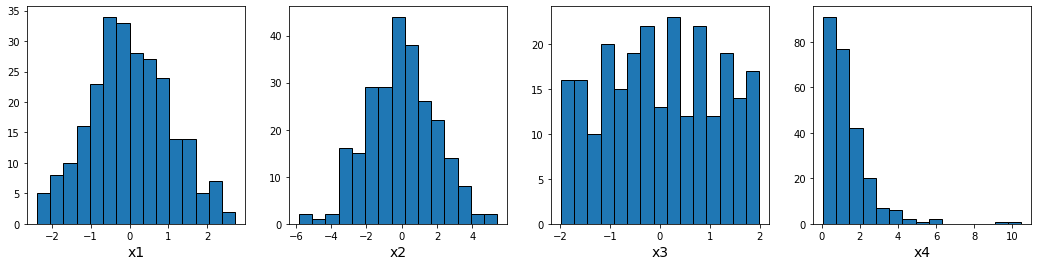

In [3]:
fig, axes = plt.subplots(ncols=4,figsize=(18,4))

for ax,label in zip(axes,['x1','x2','x3','x4']):
    ax.set_xlabel(label,fontsize=14)

axes[0].hist(x1,bins=15,edgecolor='black')
axes[1].hist(x2,bins=15,edgecolor='black')
axes[2].hist(x3,bins=15,edgecolor='black')
axes[3].hist(x4,bins=15,edgecolor='black')

fig.show()

## Medidas de localização

### Média

A média é uma medida de tendência central que representa o valor médio de um conjunto de dados. Ela é obtida pela soma de todos os valores observados dividida pelo número total de observações, fornecendo uma estimativa do valor central da distribuição.


$$\overline{\mathbf{x}} = \frac{1}{n}\sum_{i=1}^{n}x_i$$

- $\overline{\mathbf{x}}$ = média do vetor  
- $x_i$ = i-ésimo valor observado  
- $n$ = número total de observações

In [4]:
# Criando uma matriz a partir dos vetores x1, x2, x3 e x4
X = np.asarray([x1,x2,x3,x4])
X.shape

(4, 250)

In [6]:
#Calculando a média de x1
print(f'Valor médio de x1={np.mean(x1)}')

Valor médio de x1=-0.016804589017686385


In [7]:
np.mean(X,axis=1)

array([-0.01680459,  0.08818529, -0.01561318,  1.42852136])

In [8]:
#Ou utilizar a matriz X para computar a média de todas as variáveis
print(' '*8+'x1'+' '*9+'x2'+' '*9+'x3'+' '*9+'x4')
print(np.mean(X,axis=1))

        x1         x2         x3         x4
[-0.01680459  0.08818529 -0.01561318  1.42852136]


---

### Mediana

A mediana é o valor central em um conjunto de números e é equivalente ao 50º percentil. Em outras palavras, a mediana é o ponto médio de um conjunto de números, no qual metade dos valores é menor que a mediana e a outra metade é maior que ela. Diferentemente da média, a mediana é menos sensível à presença de valores extremos (*outliers*).

$$
\text{mediana}(\mathbf{x})=
\begin{cases}
\frac{1}{2}\left(x_{\frac{n}{2}} + x_{\frac{n}{2}+1}\right), & \text{se } n \text{ for par} \\
x_{\frac{n+1}{2}}, & \text{se } n \text{ for ímpar}
\end{cases}
$$

onde:

- $\mathbf{x}$ = vetor contendo as observações ordenadas  
- $x_i$ = i-ésimo elemento do vetor  

In [ ]:
#Ex1: Criando um vetor de números inteiros aleatórios entre 0 e 5, com 11 elementos
x = np.random.randint(0,6,11)
x

array([1, 1, 0, 4, 2, 0, 1, 2, 4, 0, 0])

In [10]:
# Ordenando o vetor x em ordem crescente usando a função sort() do NumPy
# Obs: a função sort() do NumPy retorna um novo array ordenado, enquanto o método sort() de um array do NumPy ordena o array original no local.

x.sort()
x

array([0, 0, 0, 0, 1, 1, 1, 2, 2, 4, 4])

In [14]:
#Consultando o tamanho do vetor x usando o atributo shape
print(x.shape,len(x))

(11,) 11


In [16]:
# Calculo da mediana do vetor x

(x[int(len(x)/2)-1]+x[int(len(x)/2)])/2

1.0

In [ ]:
def mediana(x):
    """
    Input: x - vetor de números
    
    Output: mediana de x
    """
    #Tranformando x em um array do NumPy   
    x: np.ndarray = np.asarray(x)
    
    return (x[int(x.shape[0]/2)-1]+x[int(x.shape[0]/2)])/2

In [17]:
mediana(x)

1.0

In [18]:
# Realizando o mesmo cálculo utilizando a função median() do NumPy
np.median(x)

1.0

In [19]:
# Usando a função median() do NumPy para calcular a mediana de cada variável da matriz X
np.median(X,axis=1)

array([ 0.02606999,  0.19276652, -0.0899438 ,  1.01530536])

### <center> Quartil e percentis </center>

Os **quartis** são medidas de posição obtidas após ordenar o vetor de dados em ordem crescente. Eles dividem o conjunto de dados em quatro partes aproximadamente iguais.

- **Primeiro quartil** ($q_{1/4}$ ou $Q_1$) – valor abaixo do qual estão aproximadamente 25% das observações (25º percentil).

- **Segundo quartil** ($q_{2/4}$ ou $Q_2$) – valor abaixo do qual estão aproximadamente 50% das observações. Corresponde à **mediana** (50º percentil).

- **Terceiro quartil** ($q_{3/4}$ ou $Q_3$) – valor abaixo do qual estão aproximadamente 75% das observações (75º percentil).

Os **percentis** são uma generalização dos quartis. Nesse caso, o vetor ordenado é dividido em **100 partes**, indicando a posição relativa de um valor dentro da distribuição de dados.

Por exemplo:

- **P25** corresponde ao primeiro quartil  
- **P50** corresponde à mediana  
- **P75** corresponde ao terceiro quartil

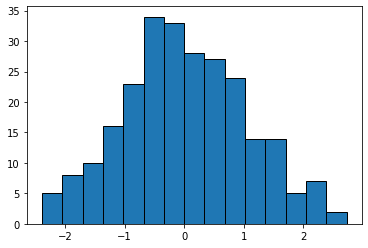

In [14]:
plt.hist(x1,bins=15,edgecolor='black')

plt.show()

In [20]:
# Obtendo o primeiro quartil de x1 usando a função quantile() do NumPy
np.quantile(x1,q=0.25)

-0.6654047183479562

In [21]:
# Obtendo os quartis de x1 usando a função quantile() do NumPy
for i in np.arange(0.0,1.25,0.25):
    print(f'Quartil {int(i*100)}:  {np.quantile(x1,q=i)}')

Quartil 0:  -2.6801284356619415
Quartil 25:  -0.6654047183479562
Quartil 50:  0.02606998944238824
Quartil 75:  0.5787053009085905
Quartil 100:  2.256076143929935


In [22]:
# Obtendo os percentis de x1 usando a função percentile() do NumPy
for i in range(10,110,10):
    print(f'Percentil {i}:  {np.percentile(x1,q=i)}')

Percentil 10:  -1.2363681689432315
Percentil 20:  -0.8282153756580296
Percentil 30:  -0.5040797793356692
Percentil 40:  -0.23905401971392692
Percentil 50:  0.02606998944238824
Percentil 60:  0.24661706421255677
Percentil 70:  0.4193217099170521
Percentil 80:  0.7894532088066756
Percentil 90:  1.1376501958482412
Percentil 100:  2.256076143929935


### Boxplot

O **intervalo interquartil (IQR)** corresponde à diferença entre o terceiro e o primeiro quartil:

$$
IQR = Q_3 - Q_1
$$

Essa medida representa a dispersão dos **50% centrais dos dados** e é menos sensível à presença de valores extremos do que outras medidas de variabilidade.

O **IQR** é frequentemente utilizado na detecção de **outliers**. A partir dele, define-se um intervalo esperado para os dados:

**Limite inferior**

$$
x_i < Q_1 - \alpha \cdot IQR
$$

**Limite superior**

$$
x_i > Q_3 + \alpha \cdot IQR
$$

onde $\alpha$ é uma constante. Na prática, adota-se frequentemente $\alpha = 1.5$, especialmente na construção de **gráficos de caixa (boxplots)**. Valores que ficam fora desse intervalo são considerados **potenciais outliers**.

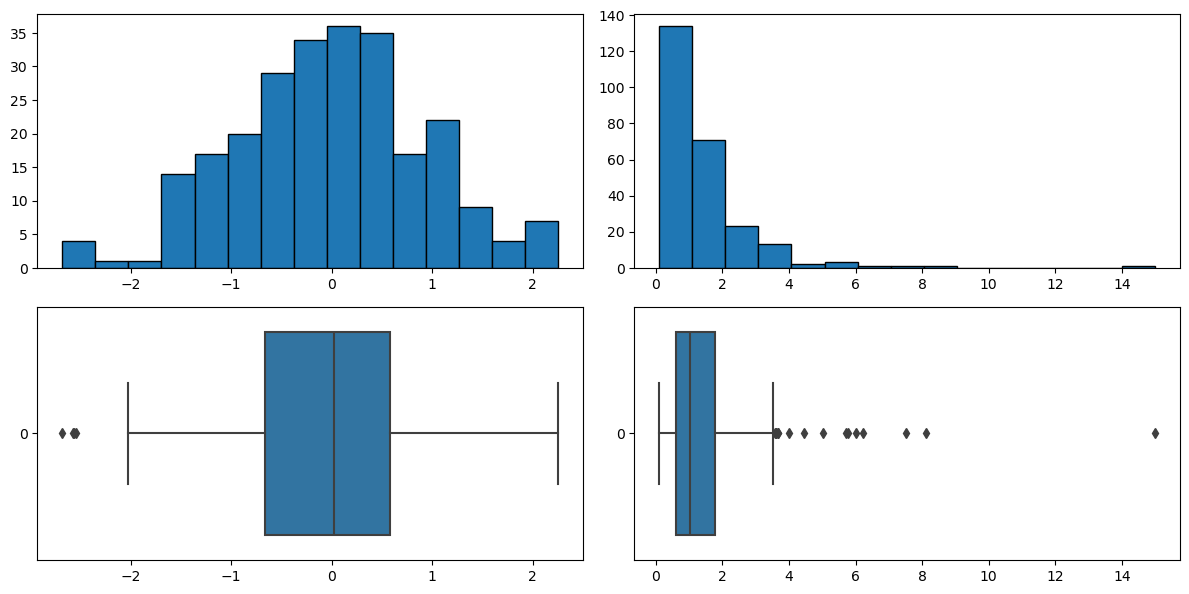

In [25]:
fig, axes = plt.subplots(nrows=2,ncols=2,figsize=(12,6))

axes[0][0].hist(x1,bins=15,edgecolor='black')

axes[0][1].hist(x4,bins=15,edgecolor='black')

sns.boxplot(x1,ax=axes[1][0],orient='horizontal')

sns.boxplot(x4,ax=axes[1][1],orient='horizontal')

fig.tight_layout()

### Média Truncada


A **média truncada** é uma variação da média aritmética em que parte dos valores extremos do conjunto de dados é removida antes do cálculo. Esse procedimento reduz a influência de *outliers* ou valores não representativos.

Em algumas aplicações, é possível limitar os valores considerados no cálculo da média com base em critérios estatísticos ou em limites não realistas para o fenômeno analisado. No processamento de dados geofísicos, por exemplo, podem ser excluídas medições que não correspondem a valores fisicamente plausíveis, por exemplo: densidade igual a 30 g/$\text{cm}^3$.

In [26]:
# Transformando a matriz X em um DataFrame do Pandas, atribuindo os nomes das colunas como 'x1', 'x2', 'x3' e 'x4'
df = pd.DataFrame(X.T,columns=['x1','x2','x3','x4'])

In [27]:
df.head()

,x1,x2,x3,x4
0,0.053294,-0.387531,-1.961293,0.139777
1,0.597400,1.869727,-0.247659,0.952923
2,-0.190907,0.679407,0.428000,0.450511
3,0.068077,0.745058,0.774078,0.909933
4,1.120265,0.196672,1.856099,2.137492


In [28]:
df.x1.mean()

-0.016804589017686385

trucando os valores de x1 entra o 2ºpercentil e o 98ºpercentil

In [29]:
df.x1[(df.x1 < df.x1.quantile(q=0.98))&
      (df.x1 > df.x1.quantile(q=0.02))].mean()

-0.010404693099262417

## <center> Medidas de Dispersão e Distribuição </center>

As medidas definidas em torno da média de um conjunto de valores, são em sua maioria, denominadas uma medida de momento:

$$M(\mathbf{x})=\frac{\sum_{i=1}^n (x_i-\overline{\mathbf{x}})^k}{(n-1)}$$

onde:

k=2 é o segundo momento central, chamado de variância;

k=3 é a obliquidade (<i>skweness</i>), ou terceiro momento central; e

k= 4 é a curtose (<i>kurtosis</i>), ou quarto momento central.


---

### Variância

A **variância** é uma das medidas mais utilizadas para avaliar o grau de espalhamento dos valores de uma variável $\mathbf{x}$ em torno de sua média:

$$
\mathrm{var} = \frac{1}{n-1}\sum_{i=1}^{n} (x_i-\overline{x})^2
$$

A raiz quadrada da variância é denominada **desvio padrão** ($\sigma$):

$$
\sigma = \sqrt{\mathrm{var}}
$$

Para ilustrar esse conceito, utilizaremos as distribuições $\mathbf{x_1}$ e $\mathbf{x_2}$, ambas gaussianas.

In [30]:
print(3*'\t'+'x1'+ 3*'\t'+ 'x2')
print('Variância:'+'\t'+f'{df.x1.var()}'+'\t'+f'{df.x2.var()}')
print('Desvio Padrão:'+'\t'+f'{df.x1.std()}'+'\t'+f'{df.x2.std()}')

			x1			x2
Variância:	0.8926286850956089	4.641008241058176
Desvio Padrão:	0.9447902863046428	2.154299942222108


C:\Users\Acer3\AppData\Local\Temp\ipykernel_43900\1918291363.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


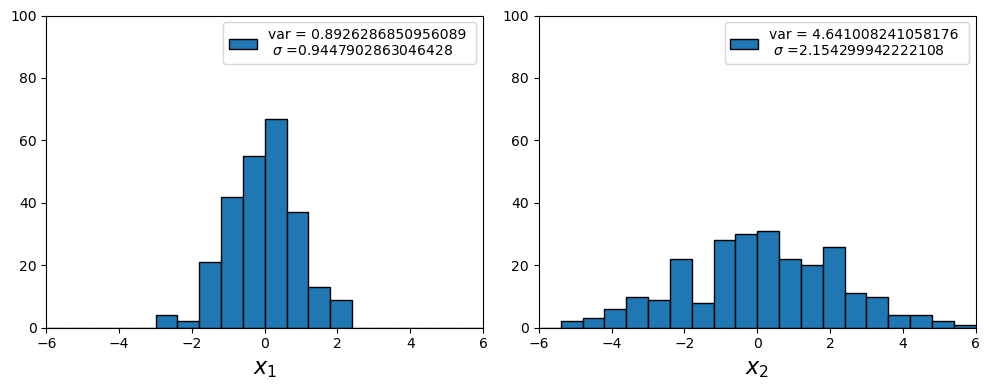

In [ ]:
fig, axes = plt.subplots(ncols=2,figsize=(10,4))

for ax in axes:
    ax.set_xlim(-6,6)
    ax.set_ylim(0,100)

axes[0].hist(x1,bins=20,edgecolor='black',range=(-6,6),
             label=f'var = {df.x1.var()} \n $\sigma$ ={df.x1.std()}')
axes[0].set_xlabel('$x_1$',fontsize=16)
axes[0].legend()

axes[1].hist(x2,bins=20,edgecolor='black',range=(-6,6),
             label=f'var = {df.x2.var()} \n $\sigma$ ={df.x2.std()}')
axes[1].set_xlabel('$x_2$',fontsize=16)
axes[1].legend()

fig.tight_layout()

fig.show()



In [34]:
from scipy.stats import skew,kurtosis

### Obliquidade

A **obliquidade**, ou *skewness* em inglês, mede o grau de **assimetria** da distribuição dos dados em torno da média. Essa medida está associada ao **terceiro momento central** da distribuição (quando $k=3$). Para tornar essa medida adimensional e independente da escala dos dados, é comum normalizá-la pelo cubo do desvio padrão:

$$
M(\mathbf{x}) = \frac{1}{n-1}\sum_{i=1}^{n} \frac{(x_i - \overline{x})^3}{\sigma^3}
$$

In [35]:
#Criando uma distribuição assimétrica a direita
df['x5'] = (np.random.lognormal(mean=-2,sigma=0.7,size=250)*-1)+1

Para exemplificar, iremos utilizar as distribuições $\mathbf{x_1}$, $\mathbf{x_4}$ e $\mathbf{x_5}$

In [36]:
print(3*'\t'+'Obliquidade')
for i,j in zip(df.columns,skew(df)):
    print(i,j)

			Obliquidade
x1 -0.06894831374215533
x2 -0.15771872921826965
x3 0.048524021461469086
x4 4.251728867944247
x5 -3.70531334037005


C:\Users\Acer3\AppData\Local\Temp\ipykernel_43900\2262804757.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


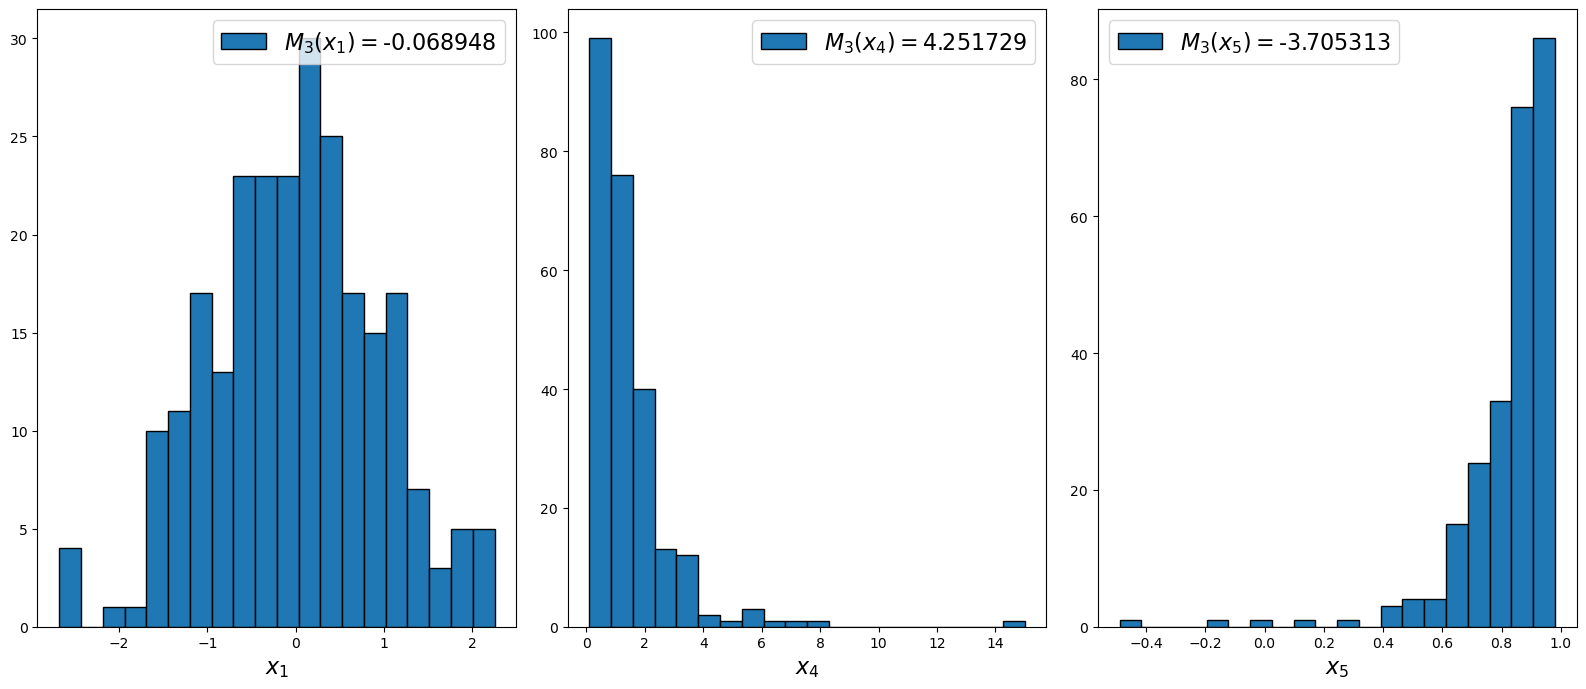

In [ ]:
fig,axes = plt.subplots(ncols=3,figsize=(16,7))

axes[0].hist(x1,bins=20,edgecolor='black',
             label=f'$M_3(x_1)=${skew(df.x1):f}')
axes[0].set_xlabel('$x_1$',fontsize=16)

axes[1].hist(x4,bins=20,edgecolor='black',
             label=f'$M_3(x_4)=${skew(df.x4):f}')
axes[1].set_xlabel('$x_4$',fontsize=16)

axes[2].hist(df.x5,bins=20,edgecolor='black',
             label=f'$M_3(x_5)=${skew(df.x5):f}')
axes[2].set_xlabel('$x_5$',fontsize=16)

for ax in axes:
    ax.legend(fontsize=16)

fig.tight_layout()

fig.show()

### Curtose

A **curtose**, ou *kurtosis* em inglês, mede o grau de concentração dos dados no centro e nas caudas da distribuição. Essa medida está associada ao **quarto momento central** da distribuição (quando $k=4$). Ela indica se a distribuição apresenta um pico mais acentuado ou se é mais "achatada" em relação a uma distribuição normal.

$$
M(\mathbf{x}) = \frac{1}{n-1}\sum_{i=1}^{n} \frac{(x_i - \overline{x})^4}{\sigma^4}
$$

Para exemplificar, utilizaremos as distribuições $\mathbf{x_1}$, $\mathbf{x_4}$ e $\mathbf{x_5}$

In [40]:
print(3*'\t'+'Curtose')
for i,j in zip(['x1', 'x2', 'x4'],kurtosis(df[['x1', 'x2', 'x4']])):
    print(i,j)

			Curtose
x1 -0.052402160752428095
x2 -0.12323502707526535
x4 29.013213213022382


In [41]:
x_n = np.concatenate((x1,np.random.normal(scale=0.05,size=100)))

C:\Users\Acer3\AppData\Local\Temp\ipykernel_43900\4123752244.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


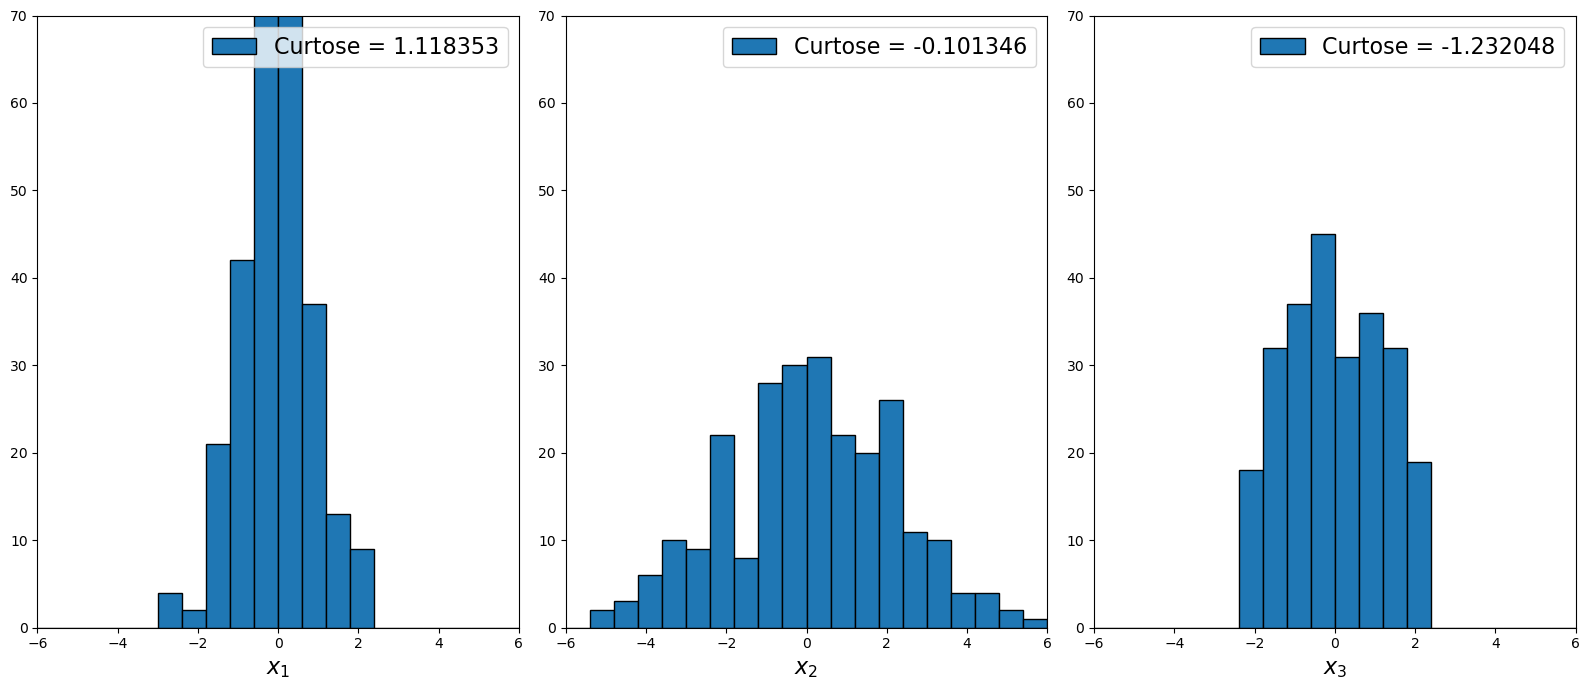

In [ ]:
fig, axes = plt.subplots(ncols=3,figsize=(16,7))

for ax in axes:
    ax.set_xlim(-6,6)
    ax.set_ylim(0,70)

axes[0].hist(x_n,bins=20,edgecolor='black',range=(-6,6),
             label=f'Curtose = {kurtosis(x_n):f}')
axes[0].set_xlabel('$x_1$',fontsize=16)

axes[1].hist(x2,bins=20,edgecolor='black',range=(-6,6),
             label=f'Curtose = {df.x2.kurtosis():f}')
axes[1].set_xlabel('$x_2$',fontsize=16)

axes[2].hist(x3,bins=20,edgecolor='black',range=(-6,6),
             label=f'Curtose = {df.x3.kurtosis():f}')
axes[2].set_xlabel('$x_3$',fontsize=16)

for ax in axes:
    ax.legend(fontsize=16)

fig.tight_layout()

fig.show()
